In [1]:
import torch
import pyvips as Vips
import numpy as np
from Reinhard import Reinhard
import cv2
from PIL import Image
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import os

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

def normalization(REF_IMG_PATH):
    print("Init Normalization")
    ref_image = Vips.Image.new_from_file(REF_IMG_PATH)
    normalizer = Reinhard()
    normalizer.fit(ref_image)
    return normalizer

In [4]:
def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [5]:
def predict_crop_class(model_ft, crop):
    #crop_array = np.ndarray(buffer=crop.write_to_memory(), dtype=np.uint8, shape=(tilesize, tilesize, crop.bands))
    crop_array = crop.numpy()
    crop_array = crop_array[:,:,:3]
    #crop_array = torch.from_numpy(crop_array.transpose((2,0,1)))
    #crop_array = crop_array.transpose(2,0,1)
    img = Image.fromarray(crop_array.astype('uint8'), 'RGB')
    #img = Image.fromarray(np.uint8(crop_array.transpose((2,0,1)))).convert('RGB')
    transformed_img = data_transforms["test"](img)
    transformed_img = torch.unsqueeze(transformed_img, dim=0)
    outputs = model_ft(transformed_img.to(device).float())
    _, preds = torch.max(outputs, 1)
    return preds.tolist()


def construct_wsi_mask(model_ft, stride, tilesize,REF_IMG_PATH,img):
    normalizer = normalization(REF_IMG_PATH)
    vips_img = Vips.Image.new_from_file(img, level=0)
    vips_img = normalizer.transform(vips_img)
    vinfo = getVipsInfo(vips_img)
    orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
    vips_array = np.ndarray(buffer=vips_img.write_to_memory(), dtype=np.uint8, shape=(vips_img.height, vips_img.width, vips_img.bands))
    vips_array = vips_array[:,:,:3]
    vips_array_copy =vips_array.copy()
    masked_image = np.zeros((orig_h,orig_w,3))
    count_predictions = {"white":0,"grey":0,"bg":0}
    #model_ft =  load_saved_model(path)
    for y_val in range(0, orig_h-stride, stride):
        for x_val in range(0, orig_w-stride, stride): 
                if y_val + tilesize < orig_h and x_val + tilesize < orig_w:
                    crop = vips_img.crop(x_val, y_val, tilesize, tilesize)
                    crop_pred =  predict_crop_class(model_ft, crop)
                    #print(crop_pred)
                    if crop_pred==[0]:
                        count_predictions["white"] = count_predictions["white"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [0,154,205]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(0,154,205),30)
                    if crop_pred==[1]:
                        count_predictions["bg"] = count_predictions["bg"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [255,170,51]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(255,170,51),30)
                    if crop_pred==[2]:
                        count_predictions["grey"] = count_predictions["grey"]+1
                        masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = [128,0,128]
                        vips_array_copy = cv2.rectangle(vips_array_copy,(x_val, y_val),(x_val + tilesize,y_val + tilesize),(128,0,128),30)
        #print(count_predictions)
    return masked_image, vips_array_copy, count_predictions

def print_thumnail(img1, save_dir, filename):
    th1 = Image.fromarray(img1.astype(np.uint8))
    th1.thumbnail((1000,1000))
    th1.save(os.path.join(save_dir, filename))
    return th1
        

In [6]:
REF_IMG_PATH =  '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
img = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/././PD017_Syn1_CG.svs'
img = REF_IMG_PATH
stride = 256
tilesize = 1024
path  = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/2nqho457-logs2.pth'
save_dir = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_segmentation_output'

In [7]:
model_ft = load_saved_model(path)
masked_image, vips_array_copy, count_predictions = construct_wsi_mask(model_ft, stride, tilesize,REF_IMG_PATH,img)

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torch/cuda/__init__.py:546: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Init Normalization


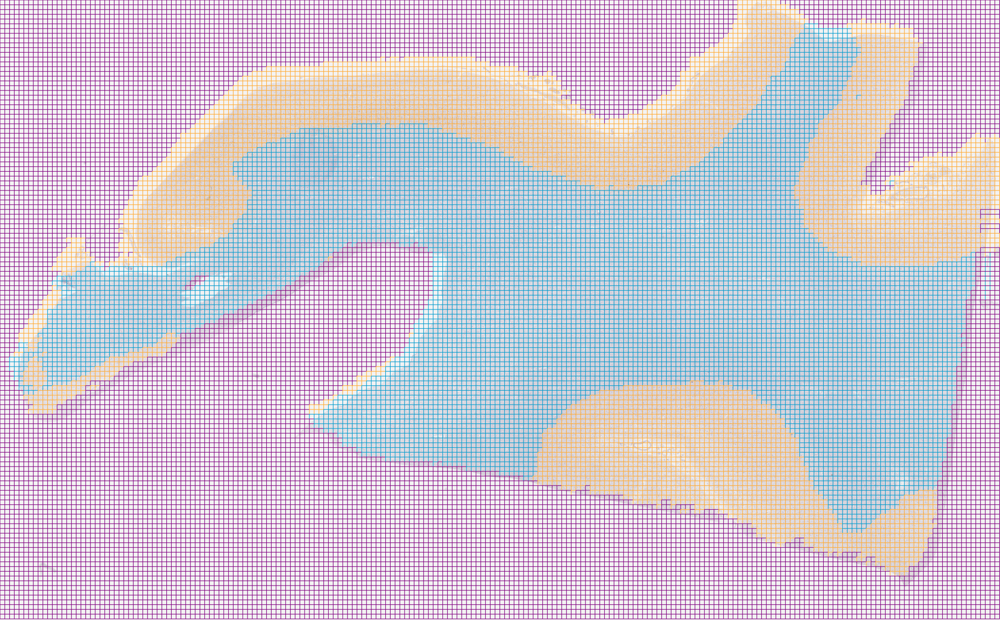

In [11]:
print_thumnail(vips_array_copy, save_dir, img.split("/")[-1].replace("svs", "png"))

In [8]:
import geojson
json_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/GeoJsons"


In [9]:
geofile="11_063_CG_aSyn_x200.svs_test.geojson"
with open(os.path.join(json_dir,geofile)) as f:
    gj = geojson.load(f)
filename = geofile.replace(".geojson","")
features = gj['features']

In [10]:
features

[{"geometry": {"coordinates": [[[44725, 2167], [44462, 2193], [44209, 2269], [44205.12, 2271.08], [44125, 2247], [43862, 2221], [43599, 2247], [43346, 2323], [43113, 2448], [42909, 2616], [42741, 2820], [42658.82, 2973.18], [42639, 2993], [42471, 3197], [42346, 3430], [42270, 3683], [42244, 3946], [42244, 3958.81], [42238, 3970], [42198.35, 4101.99], [42189, 4119], [42187, 4125.41], [42184, 4131], [42178.99, 4147.69], [42130, 4239], [42086.85, 4382.64], [42077, 4401], [42073.94, 4411.21], [42073, 4413], [42071.14, 4419.27], [42023, 4509], [42017.98, 4525.7], [41969, 4617], [41958.97, 4650.38], [41861, 4833], [41856.67, 4847.4], [41836.99, 4884.09], [41832.67, 4889.33], [41772, 4953], [41745.29, 4995.43], [41716, 5031], [41695.17, 5069.83], [41668, 5097], [41500, 5301], [41375, 5534], [41364.38, 5569.34], [41268, 5749], [41257.97, 5782.38], [41160, 5965], [41154.98, 5981.7], [41106, 6073], [41100.98, 6089.7], [41052, 6181], [41042.65, 6212.11], [40956.2, 6373.25], [40907, 6433], [40807.

In [12]:
vips_img = Vips.Image.new_from_file(img, level=0)

In [14]:
vips_array = vips_img.numpy()
vips_array = vips_array[:,:,:3]

In [16]:
vinfo = getVipsInfo(vips_img)
orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])

In [15]:
mask_shape = vips_array.shape
id_mask = np.zeros(mask_shape, dtype=np.uint8)

In [14]:
np.unique(id_mask)

array([0], dtype=uint8)

In [ ]:
from skimage import draw
for j in features:
    coords = j["geometry"]["coordinates"]
    class_type = j["properties"]["classification"]["names"][0]
    cnt = np.array(coords[0])
    cnt = cnt.astype(np.int)
    #vips_array = cv2.drawContours(vips_array, [cnt],-1, (0,0,255),40)
    coords_x, coords_y = zip(*cnt)
    fill_row_coords, fill_col_coords = draw.polygon(coords_x, coords_y, mask_shape)
    # Rowand col are flipped
    if class_type=="White":
        id_mask[fill_col_coords, fill_row_coords] = 128
    if class_type=="grey":
        id_mask[fill_col_coords, fill_row_coords] = 255   
    if class_type=="bg":
        id_mask[fill_col_coords, fill_row_coords] = 0   

/tmp/ipykernel_64677/3431533365.py:6: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  cnt = cnt.astype(np.int)


In [19]:

th1 = Image.fromarray(id_mask.astype(np.uint8))
th1.thumbnail((1000,1000))

## Optimized Codes

In [7]:
import geojson
import os
import cv2

In [15]:
def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

In [9]:
test_json_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_segmentation/test_wg/"
dlb_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases"
pdd_wsi_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases"
wsi_home_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/"

In [10]:
f_list = os.listdir(test_json_dir)

In [11]:
f_list

['11_063_CG_aSyn_x200.svs.geojson']

In [12]:
    geofile=f_list[0]
    with open(os.path.join(test_json_dir,geofile)) as f:
        gj = geojson.load(f)
    filename = geofile.replace(".geojson","")
    features = gj['features']
    if filename.startswith("PD"):
        img = os.path.join(pdd_wsi_dir, filename)
    else:
        img = os.path.join(dlb_wsi_dir, filename)
    vips_img = Vips.Image.new_from_file(img, level=0)
    vinfo = getVipsInfo(vips_img)
    orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
    vips_array=vips_img.numpy()
    vips_array = vips_array[:,:,:3]
    binary_array= np.zeros((orig_h,orig_w))
    for j in features:
        coords = j["geometry"]["coordinates"]
        class_type = j["properties"]["classification"]["names"][0]
        coords = np.array(coords[0]).astype(int)
        if class_type=="White":
            cv2.drawContours(binary_array, [coords], -1, color=(128),thickness=cv2.FILLED)
        if class_type=="grey":
            cv2.drawContours(binary_array, [coords], -1, color=(255),thickness=cv2.FILLED)
        if class_type=="bg":
            cv2.drawContours(binary_array, [coords], -1, color=(0),thickness=cv2.FILLED)
        

In [12]:
np.unique(binary_array)

array([  0., 128., 255.])

In [13]:
binary_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
th1 = Image.fromarray(binary_array.astype(np.uint8))
th1.thumbnail((1000,1000))

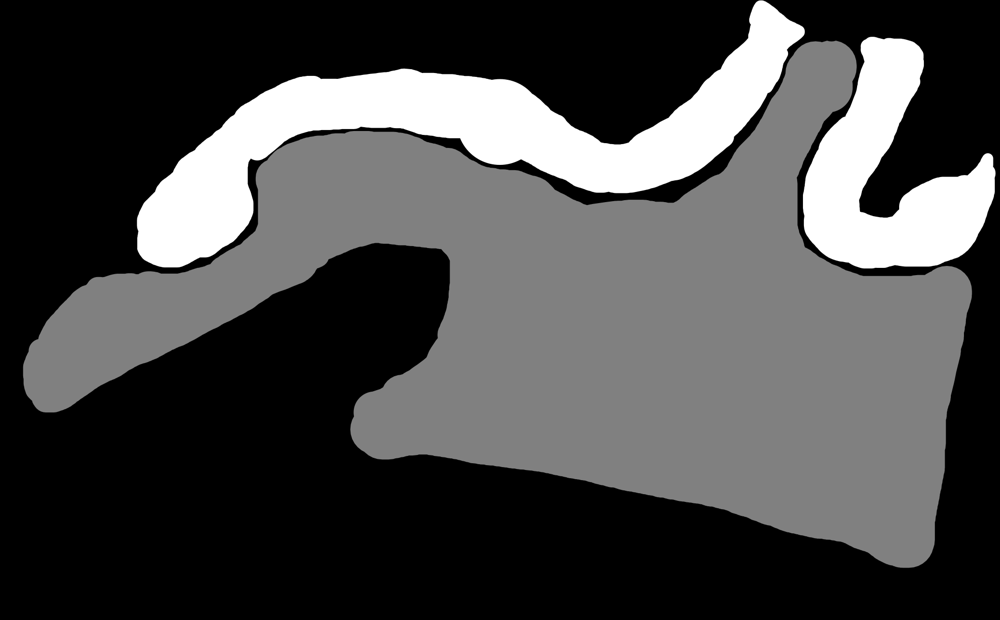

In [13]:
th1

In [10]:
def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

WGM_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [26]:
def crop2img(crop):
    crop_array = crop.numpy()
    crop_array = crop_array[:,:,:3]
    img = Image.fromarray(crop_array.astype('uint8'), 'RGB')
    return img

def predict_crop_class(model_ft, crop, data_transforms, xy):
    img = crop2img(crop)
    transformed_img = data_transforms["test"](img)
    transformed_img = torch.unsqueeze(transformed_img, dim=0)
    outputs = model_ft(transformed_img.to(device).float())
    _, preds = torch.max(outputs, 1)
    return xy, preds.tolist()

In [17]:
tilesize=1024
stride=256
xy_coords = [(x_val,y_val) for x_val in range(0, orig_w-tilesize, stride) for y_val in range(0, orig_h-tilesize, stride)]

In [36]:
len(xy_coords)

26289

In [18]:
crops = [vips_img.crop(z[0], z[1], tilesize, tilesize) for z in xy_coords]

In [40]:
from concurrent.futures import ThreadPoolExecutor, wait, ALL_COMPLETED

In [30]:
WM_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/best_models/2nqho457-logs2.pth'
model_wgm = load_saved_model(WM_model_path)

In [41]:

workers=4
exe = ThreadPoolExecutor(max_workers=workers)
futures = [exe.submit(predict_crop_class, model_wgm, crop, WGM_transforms, xy) for crop, xy in zip(crops,xy_coords)]
done, not_done = wait(futures, return_when=ALL_COMPLETED)
exe.shutdown()


: 

: 

In [19]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_list):
        super(TestDataset, self).__init__()
        self.img_list = img_list
        self.transforms = transforms.Compose([
        transforms.Resize(1024),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    def __len__(self):
        return len(self.img_list)
    
    def __getitem__(self, idx):
        img = self.img_list[idx]
        img = crop2img(img)
        transformed_img = self.transforms(img)
        transformed_img = torch.unsqueeze(transformed_img, dim=0)
        return transformed_img

In [33]:
from torch.utils.data import TensorDataset, DataLoader
valDataset = TestDataset(crops)
valDataLoader = DataLoader(valDataset, batch_size=6,shuffle=False)

def test(dataloader, model):
    model.eval()
    pred_labels = []
    with torch.no_grad():
        for X in dataloader:
            X= X.to(device).float()
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            pred_labels.extend(preds.tolist())
            #print(preds.tolist())
    return pred_labels

pred_labels =  test(valDataset, model_wgm)

In [35]:
len(pred_labels)

26289

In [38]:
tilesize = 1024
masked_image = np.zeros((orig_h,orig_w))
for pred, z in zip(pred_labels,xy_coords):
    if pred==0:
        masked_image[z[0]:z[0]+tilesize, z[1]:z[1]+tilesize] = 128 
    if pred==1:
        masked_image[z[0]:z[0]+tilesize, z[1]:z[1]+tilesize] = 255
    
# Ran for 50 mins 

In [17]:
WM_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/best_models/2nqho457-logs2.pth'
model_wgm = load_saved_model(WM_model_path)
stride = 256
tilesize = 1024
masked_image = np.zeros((orig_h,orig_w))
count_predictions = {"white":0,"grey":0,"bg":0}  
for y_val in range(0, orig_h-tilesize, stride):
    for x_val in range(0, orig_w-tilesize, stride): 
            if y_val + tilesize < orig_h and x_val + tilesize < orig_w:
                crop = vips_img.crop(x_val, y_val, tilesize, tilesize)
                crop_pred =  predict_crop_class(model_wgm, crop, WGM_transforms)
                if crop_pred==[0]:
                    masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = 128
                    count_predictions["white"] = count_predictions["white"]+1
                if crop_pred==[2]:
                    masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = 0
                    count_predictions["bg"] = count_predictions["bg"]+1
                if crop_pred==[1]:
                    count_predictions["grey"] = count_predictions["grey"]+1
                    masked_image[x_val:x_val+tilesize, y_val:y_val+tilesize] = 255

In [19]:
from torchmetrics.functional.classification import dice

In [20]:
target = torch.tensor([1, 1, 2, 0])
preds = torch.tensor([2, 0, 2, 1])
dice(preds, target, average='micro')

tensor(0.2500)